In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [10]:
dfDef = pd.read_csv("../impl/resources/gdpdef.csv")
dfDef.head()
dfDef['Year'] = dfDef['date'].str.split('-').str[0].astype(int)
arrDef = dfDef.set_index('Year')['gdpdef']
arrDef

Year
1947     11.425
1948     12.065
1949     12.046
1950     12.189
1951     13.059
         ...   
2021    110.157
2022    118.012
2023    122.382
2024    125.422
2025    128.248
Name: gdpdef, Length: 79, dtype: float64

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

common = {
    1975: {"pop": 35281, "gdp":  62362},
    1990: {"pop": 42869, "gdp": 244124},
    2005: {"pop": 48185, "gdp": 620981},
    2010: {"pop": 49554, "gdp": 766940},
    2015: {"pop": 51015, "gdp": 891340},
    2020: {"pop": 51836, "gdp": 988915},
    2025: {"pop": 51684, "gdp": 1107523}, # 2020년 GDP(988915)에 연도별 GDP 성장률 곱.
}

In [86]:
988915 / 51836

19.077764488000618

In [76]:
gdppc_2025 = 1107523 / 51684
gdppc_2025

21.42874003560096

In [77]:
# high
gdppc_2030 = gdppc_2025 * (1.018) ** 5
gdppc_2035 = gdppc_2030 * (1.014) ** 5
gdp_2030 = gdppc_2030 * 51949
gdp_2035 = gdppc_2035 * 52209
gdp_2030, gdp_2035

(1217062.043114464, 1311205.239847802)

In [78]:
# mid
gdppc_2030 = gdppc_2025 * (1.014) ** 5
gdppc_2035 = gdppc_2030 * (1.006) ** 5
gdp_2030 = gdppc_2030 * 51305
gdp_2035 = gdppc_2035 * 50824
gdp_2030, gdp_2035

(1178544.8193498075, 1202943.2986053214)

In [79]:
# low
gdppc_2030 = 22.477192
gdppc_2035 = 22.497110
gdp_2030 = gdppc_2030 * 50690
gdp_2035 = gdppc_2035 * 49470
gdp_2030, gdp_2035

(1139368.86248, 1112932.0317)

In [80]:
scenarios = {
    "high": {
        2030: {"pop": 51949, "gdp": 1217062},
        2035: {"pop": 52209, "gdp": 1311205},
    },
    "mid": {
        2030: {"pop": 51305, "gdp": 1178544},
        2035: {"pop": 50824, "gdp": 1202943},
    },
    "low": {
        2030: {"pop": 50690, "gdp": 1139369},
        2035: {"pop": 49470, "gdp": 1112932},
    },
}

In [81]:
records = []
for pathway, proj in scenarios.items():
    # common history
    for y, v in common.items():
        records.append((pathway, y, v["pop"], v["gdp"]))
    # pathway projections
    for y, v in proj.items():
        records.append((pathway, y, v["pop"], v["gdp"]))

df = pd.DataFrame(records, columns=["pathway", "year", "population_thous", "GDP_million"])
df["GDPpc_thous_1990$"] = df["GDP_million"] / df["population_thous"]
df = df.sort_values(["pathway", "year"]).reset_index(drop=True)

In [82]:
df

,pathway,year,population_thous,GDP_million,GDPpc_thous_1990$
0,high,1975,35281,62362,1.767580
1,high,1990,42869,244124,5.694651
2,high,2005,48185,620981,12.887434
3,high,2010,49554,766940,15.476854
4,high,2015,51015,891340,17.472116
5,high,2020,51836,988915,19.077764
6,high,2025,51684,1107523,21.428740
7,high,2030,51949,1217062,23.428016
8,high,2035,52209,1311205,25.114540
9,low,1975,35281,62362,1.767580


In [83]:
def cagr(v0, v1, n_years):
    return (v1 / v0) ** (1 / n_years) - 1

cagr_rows = []
for pathway in df["pathway"].unique():
    d = df[df["pathway"] == pathway].set_index("year")
    c1 = cagr(d.loc[2025, "GDPpc_thous_1990$"], d.loc[2030, "GDPpc_thous_1990$"], 5) * 100
    c2 = cagr(d.loc[2030, "GDPpc_thous_1990$"], d.loc[2035, "GDPpc_thous_1990$"], 5) * 100
    cagr_rows.append((pathway, c1, c2))

df_cagr = pd.DataFrame(
    cagr_rows,
    columns=["pathway", "CAGR_GDPpc_2025_2030_pct", "CAGR_GDPpc_2030_2035_pct"]
).sort_values("pathway").reset_index(drop=True)

In [84]:
df_cagr

,pathway,CAGR_GDPpc_2025_2030_pct,CAGR_GDPpc_2030_2035_pct
0,high,1.799999,1.399997
1,low,0.959942,0.017714
2,mid,1.399986,0.600009


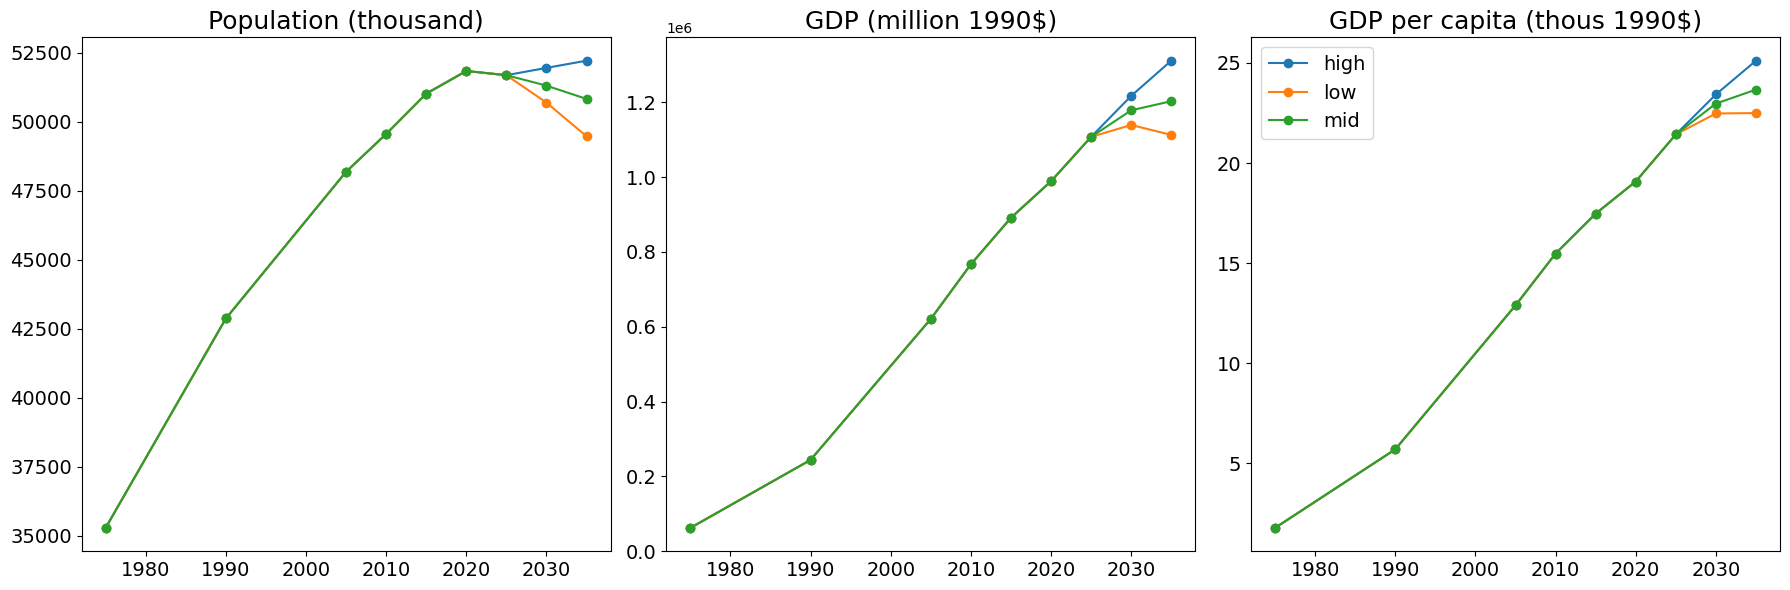

In [85]:
plt.figure(figsize=(18, 6))

# Population
ax1 = plt.subplot(1, 3, 1)
for pathway in df["pathway"].unique():
    d = df[df["pathway"] == pathway]
    ax1.plot(d["year"], d["population_thous"], marker="o", label=pathway)
ax1.set_title("Population (thousand)", fontsize=18)
# ax1.set_xlabel("Year", fontsize=16)
ax1.tick_params(axis="both", labelsize=14)

# GDP
ax2 = plt.subplot(1, 3, 2)
for pathway in df["pathway"].unique():
    d = df[df["pathway"] == pathway]
    ax2.plot(d["year"], d["GDP_million"], marker="o", label=pathway)
ax2.set_title("GDP (million 1990$)", fontsize=18)
# ax2.set_xlabel("Year", fontsize=16)
ax2.tick_params(axis="both", labelsize=14)

# GDP per capita
ax3 = plt.subplot(1, 3, 3)
for pathway in df["pathway"].unique():
    d = df[df["pathway"] == pathway]
    ax3.plot(d["year"], d["GDPpc_thous_1990$"], marker="o", label=pathway)
ax3.set_title("GDP per capita (thous 1990$)", fontsize=18)
# ax3.set_xlabel("Year", fontsize=16)
ax3.tick_params(axis="both", labelsize=14)

ax3.legend(fontsize=14, loc="best")

plt.tight_layout()
plt.show()